# n-SBC: Explainability

This notebook demonstrates the explainability features of n-SBC: the Z-matrix, per-sample feature importance, and global feature importance.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

from nsbc import NSBCClassifier
from nsbc.tools import (
    plot_chunk_similarity,
    plot_feature_importances,
    plot_similarity_heatmap,
    plot_z_scores,
)

## Train the model

In [2]:
data = np.loadtxt("../tests/cryotherapy.csv", delimiter=",")
X, y = data[:, :-1], data[:, -1]
feature_names = ["sex", "age", "time", "n_warts", "type", "area"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = NSBCClassifier(n_value=3, decimals=2)
clf.fit(X_train, y_train)

,n_value,3
,decimals,2
,factor,10
,random_state,None
,verbose,0


## Get the Z-matrix

`predict_explain()` returns a `ZMatrix` object containing the full similarity matrix, per-class scores, top-u training indices, and feature importances.

In [3]:
result = clf.predict_explain(X_test)

print(f"Z-matrix shape: {result.z.shape} (n_test x n_train)")
print(f"Predictions: {result.predictions}")
print(f"Class scores shape: {result.class_scores.shape}")
print(f"Feature importances shape: {result.feature_importances.shape}")

Z-matrix shape: (18, 72) (n_test x n_train)
Predictions: [1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0.]
Class scores shape: (18, 2)
Feature importances shape: (18, 6)


## Most similar training samples

For a given test sample, inspect which training samples are the most similar (top-u neighbors) and their similarity scores.

In [4]:
sample_idx = 0
pred_label = result.predictions[sample_idx]
top_u = result.top_u_indices[sample_idx]

print(f"Test sample {sample_idx}: predicted class = {pred_label}")
print(f"Test features: {X_test[sample_idx]}")
print()

for cls_label, indices in top_u.items():
    print(f"Class {cls_label:.0f} — top-{len(indices)} neighbors:")
    for idx in indices:
        z_score = result.z[sample_idx, idx]
        print(f"  Train[{idx}]: z={z_score}, features={X_train[idx]}")
    print()

Test sample 0: predicted class = 1.0
Test features: [ 2. 15.  6.  2.  1. 30.]

Class 0 — top-3 neighbors:
  Train[32]: z=34, features=[ 2. 17. 11.  2.  1. 10.]
  Train[33]: z=33, features=[ 2.   23.   11.75 12.    3.   72.  ]
  Train[69]: z=33, features=[ 2.  36.  10.5  4.   1.   8. ]

Class 1 — top-3 neighbors:
  Train[67]: z=39, features=[ 2.  22.   4.5  2.   1.  70. ]
  Train[7]: z=37, features=[ 1.  15.   3.5  2.   1.   4. ]
  Train[12]: z=37, features=[ 2.   15.    3.75  2.    3.   70.  ]



## Z-scores visualization

Bar chart showing Hamming similarity of the test sample to all training samples, colored by class.

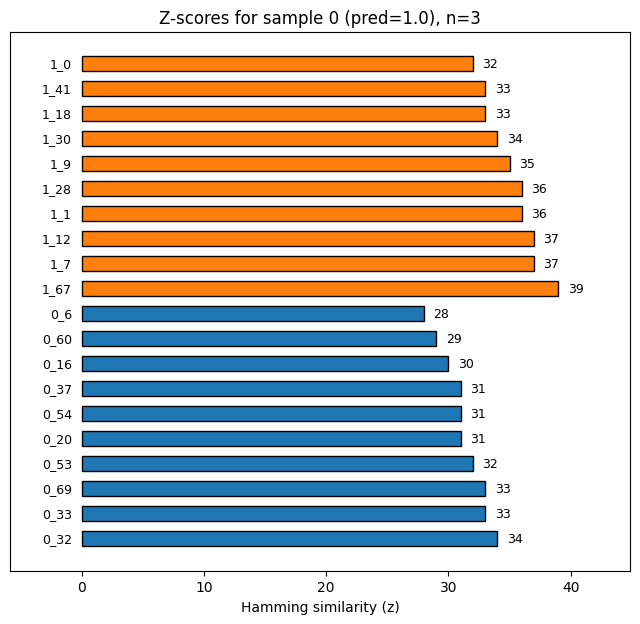

In [5]:
fig, ax = plot_z_scores(result, sample_idx=0, y_train=y_train)

## Chunk similarity (two-panel view)

Left panel shows per-feature bit-match ratios (color intensity = match %). Right panel shows total z-scores with red arrows on the top-n neighbors used for classification.

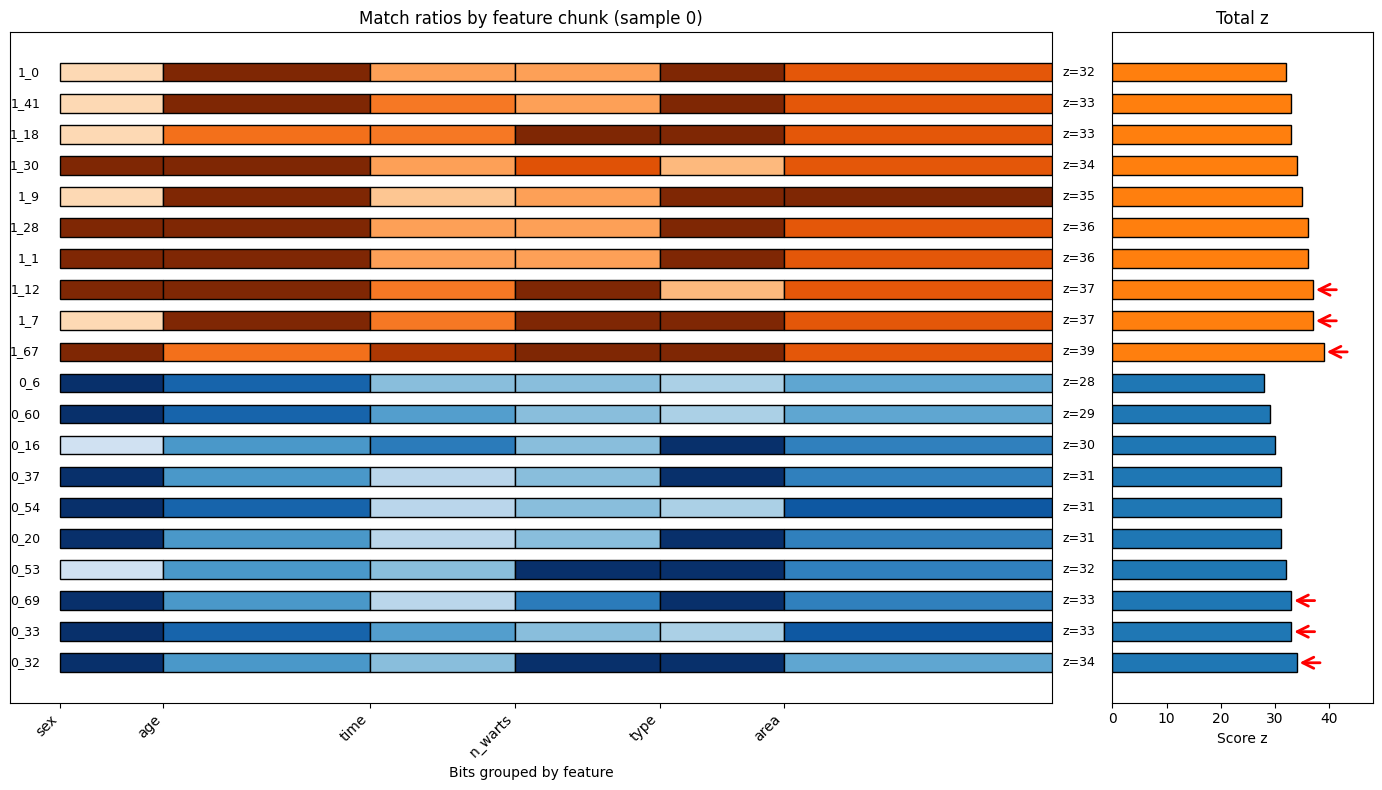

In [6]:
fig, (ax1, ax2) = plot_chunk_similarity(
    result, sample_idx=0, y_train=y_train, top_k=10, feature_names=feature_names
)

## Local feature importance (per sample)

Which features contributed most to classifying this particular test sample? The importance is the mean per-feature bit-match ratio between the test sample and its top-u neighbors of the predicted class.

In [17]:
imp = result.feature_importances[0]
order = np.argsort(-imp)
for i in order:
    print(f"{feature_names[i]}: {imp[i]:.4f}")

n_warts: 1.0000
age: 0.8667
type: 0.7778
sex: 0.7333
area: 0.6923
time: 0.6667


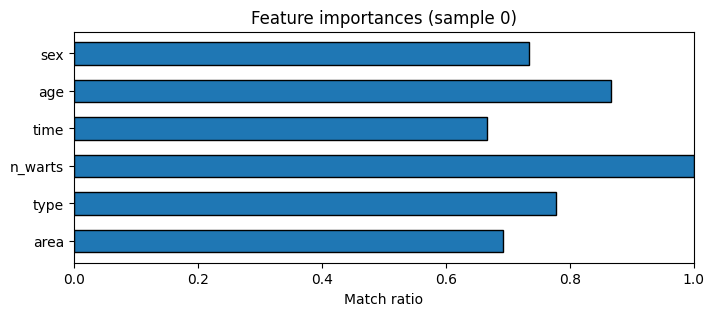

In [7]:
fig, ax = plot_feature_importances(
    result, sample_idx=0, feature_names=feature_names
)

## Feature similarity heatmap

Heatmap showing per-feature match ratios between the test sample and each of its top-u neighbors. Each cell shows how well a specific feature matches between the test sample and a training neighbor.

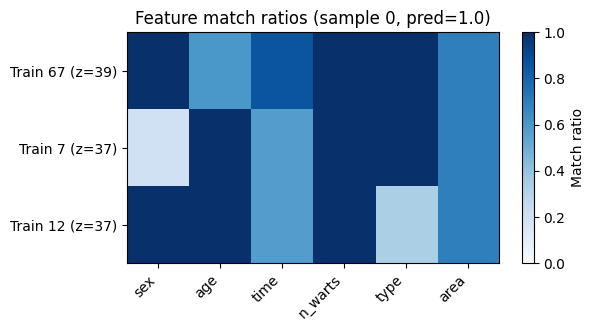

In [8]:
fig, ax = plot_similarity_heatmap(
    result, sample_idx=0, feature_names=feature_names
)

## Global feature importance

Aggregated across all test samples — analogous to SHAP global importance. Shows which features are most discriminative overall.

In [18]:
result.global_feature_importances

array([0.76296296, 0.82592593, 0.69312169, 0.67195767, 0.9382716 ,
       0.83190883])

Global feature importances:
  sex: 0.7630
  age: 0.8259
  time: 0.6931
  n_warts: 0.6720
  type: 0.9383
  area: 0.8319



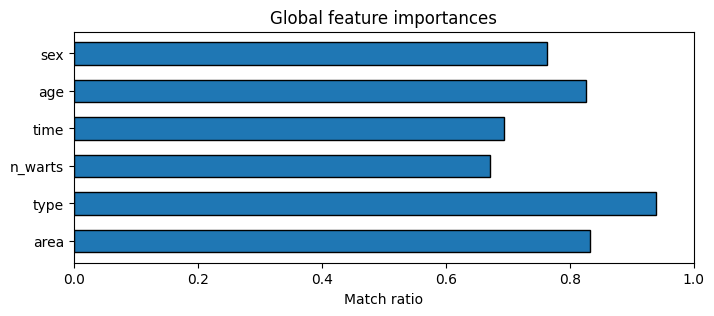

In [9]:
print("Global feature importances:")
for name, imp in zip(feature_names, result.global_feature_importances):
    print(f"  {name}: {imp:.4f}")
print()

fig, ax = plot_feature_importances(result, feature_names=feature_names)

## Full-dataset explainability

Run `predict_explain` on all training data (LOOCV-style) to get global importance across the entire dataset.

In [10]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
all_importances = []

for train_idx, test_idx in loo.split(X):
    clf_loo = NSBCClassifier(n_value=3, decimals=2)
    clf_loo.fit(X[train_idx], y[train_idx])
    z = clf_loo.predict_explain(X[test_idx])
    all_importances.append(z.feature_importances[0])

global_imp = np.mean(all_importances, axis=0)
print("LOOCV global feature importances:")
for name, imp in zip(feature_names, global_imp):
    print(f"  {name}: {imp:.4f}")

LOOCV global feature importances:
  sex: 0.7985
  age: 0.8570
  time: 0.6725
  n_warts: 0.6497
  type: 0.9630
  area: 0.8621


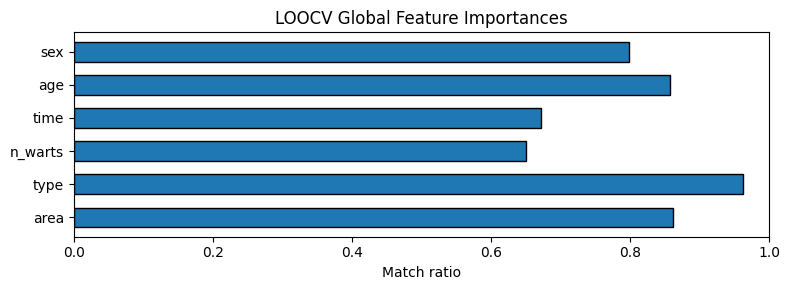

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
y_pos = np.arange(len(feature_names))
ax.barh(y_pos, global_imp, edgecolor="k", height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names)
ax.set_xlabel("Match ratio")
ax.set_title("LOOCV Global Feature Importances")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()